In [11]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [12]:
ROOT = Path.cwd().parent

In [13]:
df = pd.read_parquet(ROOT / "data" / "green_tripdata_2026-01.parquet")

In [14]:
df

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,...,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1.0,65,233,2.0,6.20,31.70,...,1.5,7.50,0.00,NaN,1.0,45.20,1.0,1.0,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5.0,66,188,5.0,5.36,50.00,...,0.0,10.20,0.00,NaN,1.0,61.20,1.0,2.0,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1.0,65,179,4.0,10.60,41.50,...,1.5,2.00,0.00,NaN,1.0,46.00,1.0,1.0,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1.0,42,141,1.0,4.20,19.80,...,1.5,0.00,0.00,NaN,1.0,25.05,2.0,1.0,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1.0,95,82,1.0,2.76,19.10,...,0.5,0.00,0.00,NaN,1.0,21.60,2.0,1.0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40267,2,2026-01-31 23:53:00,2026-02-01 00:08:00,NaN,NaN,25,228,NaN,2.57,17.98,...,0.5,3.90,0.00,NaN,1.0,23.38,NaN,NaN,NaN,0.00
40268,2,2026-01-31 23:57:00,2026-02-01 00:07:00,NaN,NaN,223,7,NaN,1.58,14.25,...,0.5,3.94,0.00,NaN,1.0,19.69,NaN,NaN,NaN,0.00
40269,6,2026-01-31 23:21:55,2026-01-31 23:47:54,NaN,NaN,256,228,NaN,8.17,3.00,...,0.5,0.00,0.00,NaN,0.3,26.02,NaN,NaN,NaN,0.00
40270,2,2026-01-31 23:43:00,2026-02-01 00:08:00,NaN,NaN,66,186,NaN,6.27,30.89,...,0.5,7.18,0.00,NaN,1.0,43.07,NaN,NaN,NaN,0.75


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40272 entries, 0 to 40271
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   VendorID               40272 non-null  int32         
 1   lpep_pickup_datetime   40272 non-null  datetime64[us]
 2   lpep_dropoff_datetime  40272 non-null  datetime64[us]
 3   store_and_fwd_flag     34858 non-null  str           
 4   RatecodeID             34858 non-null  float64       
 5   PULocationID           40272 non-null  int32         
 6   DOLocationID           40272 non-null  int32         
 7   passenger_count        34858 non-null  float64       
 8   trip_distance          40272 non-null  float64       
 9   fare_amount            40272 non-null  float64       
 10  extra                  40272 non-null  float64       
 11  mta_tax                40272 non-null  float64       
 12  tip_amount             40272 non-null  float64       
 13  tolls_amount

In [16]:
df.describe()

,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
count,40272.000000,40272,40272,34858.000000,40272.000000,40272.000000,34858.000000,40272.000000,40272.000000,40272.000000,40272.000000,40272.000000,40272.000000,0.0,40272.000000,40272.000000,34858.000000,34857.000000,34858.000000,40272.000000
mean,2.279897,2026-01-16 22:38:57.806366,2026-01-16 22:59:02.332389,1.207212,96.190480,141.878352,1.298382,12.551243,16.006925,0.823550,0.561687,2.476605,0.260190,NaN,0.922189,24.195461,1.259711,1.046562,0.851383,0.058179
min,1.000000,2025-12-27 16:49:41,2025-12-27 17:02:11,1.000000,1.000000,1.000000,0.000000,0.000000,-70.000000,-7.500000,-0.500000,-2.520000,0.000000,NaN,-1.000000,-76.500000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,2026-01-09 11:18:24,2026-01-09 11:37:25.250000,1.000000,74.000000,74.000000,1.000000,1.200000,8.600000,0.000000,0.500000,0.000000,0.000000,NaN,1.000000,14.600000,1.000000,1.000000,0.000000,0.000000
50%,2.000000,2026-01-16 14:27:16.500000,2026-01-16 14:47:26.500000,1.000000,75.000000,140.000000,1.000000,1.960000,12.800000,0.000000,0.500000,2.000000,0.000000,NaN,1.000000,20.000000,1.000000,1.000000,0.000000,0.000000
75%,2.000000,2026-01-23 19:37:11.500000,2026-01-23 19:55:24.250000,1.000000,97.000000,229.000000,1.000000,3.470000,19.100000,1.000000,0.500000,3.770000,0.000000,NaN,1.000000,28.860000,1.000000,1.000000,2.750000,0.000000
max,6.000000,2026-02-01 21:08:36,2026-02-01 21:15:02,99.000000,265.000000,265.000000,9.000000,179830.920000,960.000000,7.500000,4.250000,300.000000,85.000000,NaN,1.000000,961.000000,4.000000,2.000000,2.750000,0.750000
std,1.233095,NaN,NaN,1.018101,55.683047,77.583150,0.950439,1033.875580,14.951959,1.332193,0.321908,3.564317,1.583427,NaN,0.245158,17.177547,0.471217,0.210701,1.271401,0.200626


In [17]:
df["PU_DO"] = (
    df["PULocationID"].astype(str)
    + "_"
    + df["DOLocationID"].astype(str)
)


In [18]:
df["duration"] = (df["lpep_dropoff_datetime"] - df["lpep_pickup_datetime"]).dt.total_seconds() / 60

In [19]:
df.columns

Index(['VendorID', 'lpep_pickup_datetime', 'lpep_dropoff_datetime',
       'store_and_fwd_flag', 'RatecodeID', 'PULocationID', 'DOLocationID',
       'passenger_count', 'trip_distance', 'fare_amount', 'extra', 'mta_tax',
       'tip_amount', 'tolls_amount', 'ehail_fee', 'improvement_surcharge',
       'total_amount', 'payment_type', 'trip_type', 'congestion_surcharge',
       'cbd_congestion_fee', 'PU_DO', 'duration'],
      dtype='str')

In [44]:
X = df[["PU_DO", "trip_distance"]]
y = df["duration"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
dv = DictVectorizer()
X_train = dv.fit_transform(X_train.to_dict(orient="records"))
X_test = dv.transform(X_test.to_dict(orient="records"))


In [24]:

lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5085,)","[ 0.49, 1.62, 8.69,...,-35.97,-14.42, -0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,35.29
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5085


In [25]:
lr_pred= lr.predict(X_test)
lr_rmse = root_mean_squared_error(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)

In [26]:
print(f"Linear Regression RMSE: {lr_rmse:.2f}")
print(f"Linear Regression MAE: {lr_mae:.2f}")

Linear Regression RMSE: 76.31
Linear Regression MAE: 13.63


In [27]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [28]:
rf_pred = rf.predict(X_test)
rf_rmse = root_mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

In [29]:
print(f"Random Forest RMSE: {rf_rmse:.2f}")
print(f"Random Forest MAE: {rf_mae:.2f}")

Random Forest RMSE: 80.27
Random Forest MAE: 11.14


In [30]:
df["duration"].describe()

count    40272.000000
mean        20.075434
std         69.852105
min          0.000000
25%          8.100000
50%         12.883333
75%         20.050000
max       1439.800000
Name: duration, dtype: float64

<Axes: >

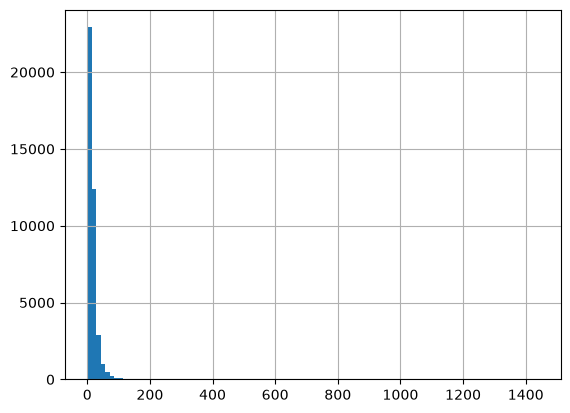

In [31]:
df['duration'].hist(bins=100)

<Axes: >

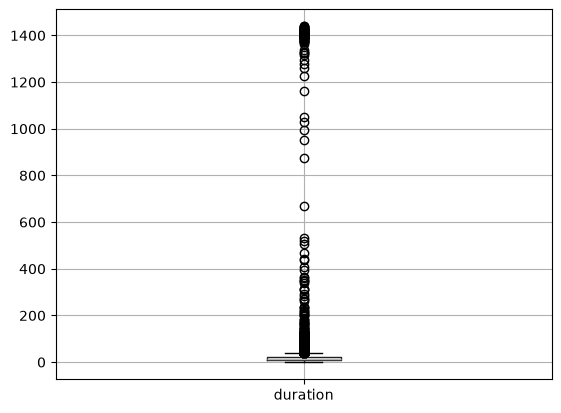

In [32]:
df[['duration']].boxplot()

In [ ]:
def remove_outliers(df, column, threshold=0.95):
    
    return df[df[column] < df[column].quantile(threshold)]

<Axes: >

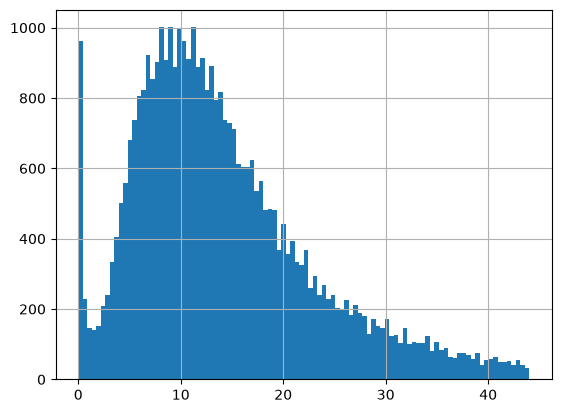

In [34]:
remove_outliers(df, 'duration', threshold=0.95)['duration'].hist(bins=100)

<Axes: >

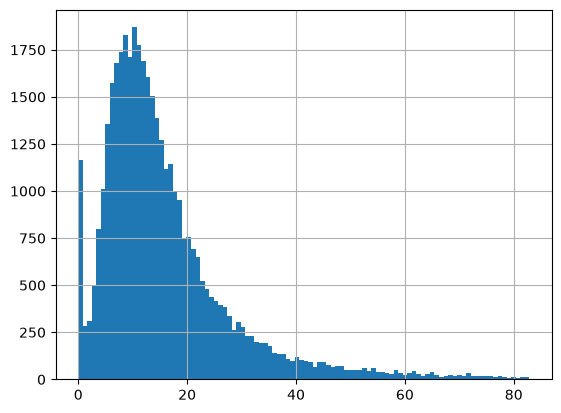

In [35]:
remove_outliers(df, 'duration', threshold=0.99)['duration'].hist(bins=100)

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
threshold = y_train.quantile(0.95)

mask = y_train < threshold
X_train = X_train[mask]
y_train = y_train[mask]



In [49]:
dv = DictVectorizer()
X_train = dv.fit_transform(X_train.to_dict(orient="records"))
X_test = dv.transform(X_test.to_dict(orient="records"))

In [50]:
lr2 = LinearRegression()
lr2.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4096,)","[ 8.95, 10.73, 13.23,...,-24.91,-14.51, -0. ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.26
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4096


In [51]:
lr2predictions = lr2.predict(X_test)
print(f"Linear Regression RMSE after removing outliers: {root_mean_squared_error(y_test, lr2predictions):.2f}")
print(f"Linear Regression MAE after removing outliers: {mean_absolute_error(y_test, lr2predictions):.2f}") 

Linear Regression RMSE after removing outliers: 73.89
Linear Regression MAE after removing outliers: 10.09


In [52]:
rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X_train, y_train) 

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [53]:
rf2_predictions = rf2.predict(X_test)
print(f"Random Forest RMSE after removing outliers: {root_mean_squared_error(y_test, rf2_predictions):.2f}")
print(f"Random Forest MAE after removing outliers: {mean_absolute_error(y_test, rf2_predictions):.2f}")

Random Forest RMSE after removing outliers: 73.64
Random Forest MAE after removing outliers: 9.16


In [ ]:
import pickle

with open( ROOT / "models/baseline.pkl", "wb") as f:
    pickle.dump((dv, rf2), f)